**Projeto: Nur Mah Museum**

**Candidata:** Laura Vieira

Análise do cenário financeiro de museus nos EUA para apoiar a estratégia de captação de recursos.

In [ ]:
%pip install pandas numpy matplotlib seaborn scikit-learn

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('data/museums.csv', low_memory=False)

df_clean = df.drop_duplicates(subset=['Museum Name', 'State (Administrative Location)', 'City (Administrative Location)']).copy()
df_clean['Income'] = df_clean['Income'].fillna(df_clean.groupby('Museum Type')['Income'].transform('median'))
df_clean = df_clean.dropna(subset=['Income'])

**1. Tratamento de Dados**
* **Receitas nulas:** Preenchidas com a mediana por tipo de museu para evitar distorções causadas por *outliers* bilionários.
* **Duplicados:** Removidos.

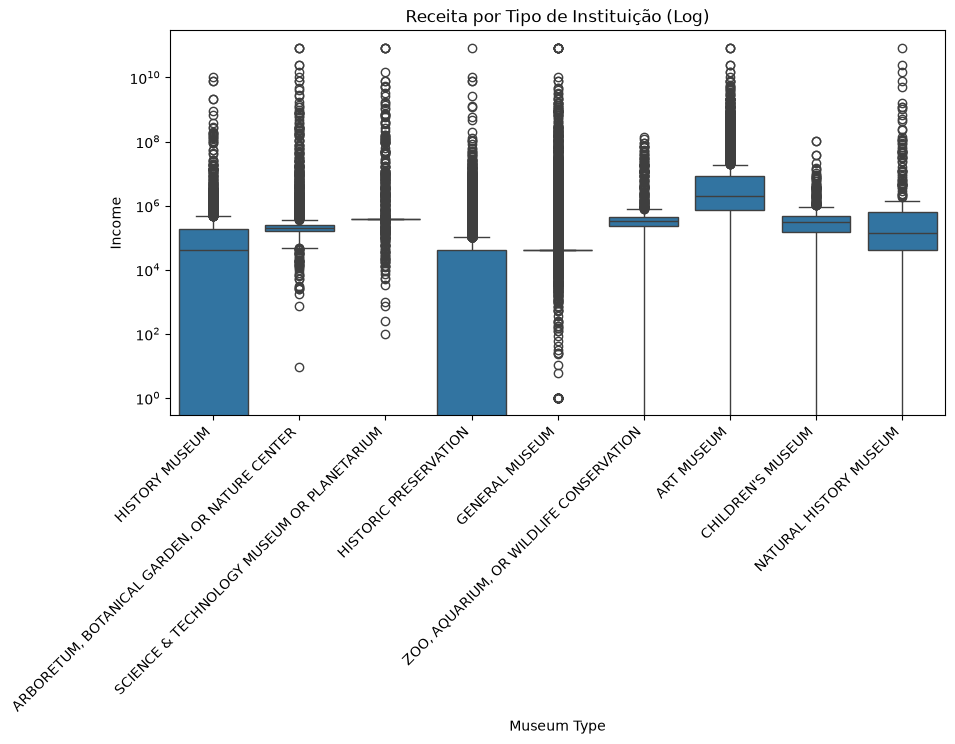

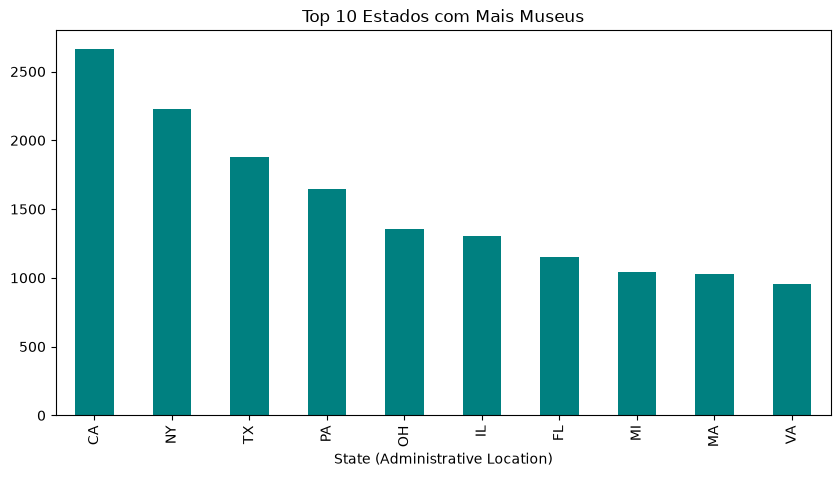

In [12]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='Museum Type', y='Income').set_yscale('log')
plt.xticks(rotation=45, ha='right')
plt.title('Receita por Tipo de Instituição (Log)')
plt.show()

top_estados = df_clean['State (Administrative Location)'].value_counts().head(10)
top_estados.plot(kind='bar', figsize=(10, 5), color='teal', title='Top 10 Estados com Mais Museus')
plt.show()

**2. Recomendações Estratégicas**
* **Metas:** Usar a mediana de Museus de Arte como linha de base para captação.
* **Parcerias:** Criar exposições híbridas com Museus de Ciência/Zoos (que possuem maior receita) para atrair novos investidores.
* **Expansão:** Focar em estados populosos com baixa concorrência.

**3. Modelagem Preditiva (Random Forest)**

In [13]:
X = df_clean[['Museum Type', 'State (Administrative Location)']]
y = df_clean['Income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline = Pipeline([
   ('prep', ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), X.columns)])),
   ('rf', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.2f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

MAE: $146,306,476.43
R²: 0.0451
